## HR Dataset Analysis

### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Dataset

In [2]:
df = pd.read_csv('HR_Analytics.csv')
print(df.shape)
df.head()

(1480, 38)


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [3]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

### Handling Missing Values

In [4]:
missing_values = df.isnull().sum()
missing_values

missing_percentage = (df.isnull().sum()/ len(df)) * 100
missing_percentage

median_curmang = df['YearsWithCurrManager'].median()
df['YearsWithCurrManager'] = df['YearsWithCurrManager'].fillna(median_curmang)
missing_values

EmpID                        0
Age                          0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome             0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
SalarySlab                   0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StandardHours                0
StockOptionLevel             0
TotalWorkingYears            0
Training

### Handling Duplicate values

In [5]:
duplicate_values = df.duplicated().sum()
print('Duplicates',duplicate_values)

df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

Duplicates 7
0


### Handling Outliers

In [6]:
Q1 = df['DailyRate'].quantile(0.25)
Q3 = df['DailyRate'].quantile(0.75)
IQR = Q3 - Q1

#calculate Limits
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

outliers = df[(df['DailyRate'] < lower_limit) | (df['DailyRate'] > upper_limit)]

print('Number of outlier:', len(outliers))

Number of outlier: 0


### EDA (Exploratory Data Analysis)

#### Overall Attrition Rate


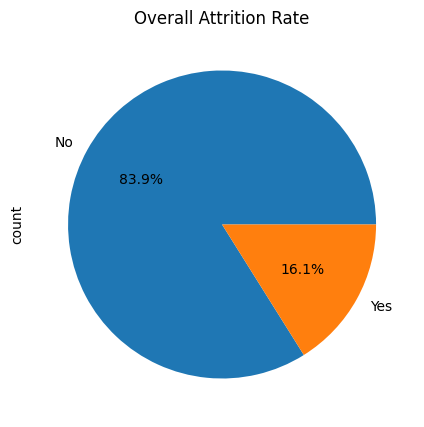

In [7]:
df['Attrition'].value_counts().plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    figsize=(8,5)
)
plt.title('Overall Attrition Rate')
plt.savefig('Overall_Attrition_Rate.png', dpi = 300, bbox_inches = 'tight')
plt.show()

#### Attrition by Department



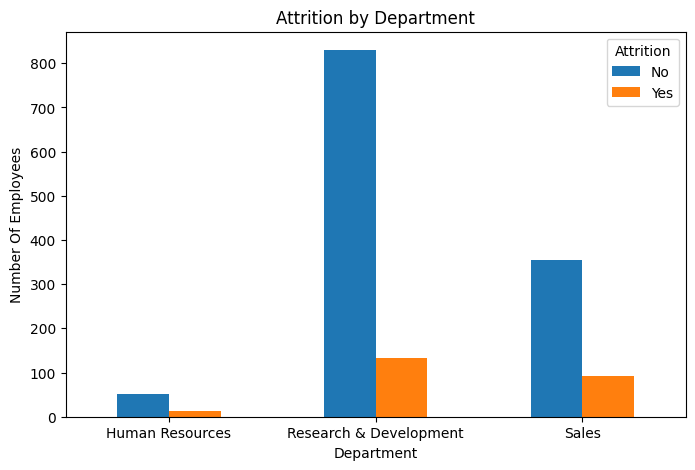

In [8]:
pd.crosstab(df['Department'], df['Attrition']).plot(kind='bar', figsize=(8,5))
plt.title('Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Number Of Employees')
plt.xticks(rotation=0)
plt.savefig('Attrition_by_Department.png', dpi = 300, bbox_inches = 'tight')
plt.show()

#### Attrition Rate by Department


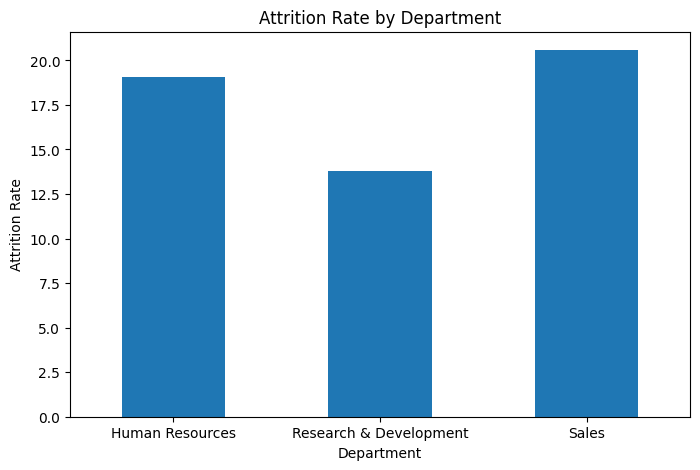

In [9]:
department_attrition_rate = pd.crosstab(df['Department'], df['Attrition'], normalize='index')* 100

department_attrition_rate['Yes'].plot(kind='bar', figsize= (8,5))
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate')
plt.xticks(rotation = 0)
plt.savefig('Attrition_Rate_by_Department.png', dpi =300, bbox_inches='tight')
plt.show()

#### Attrition by Job Role

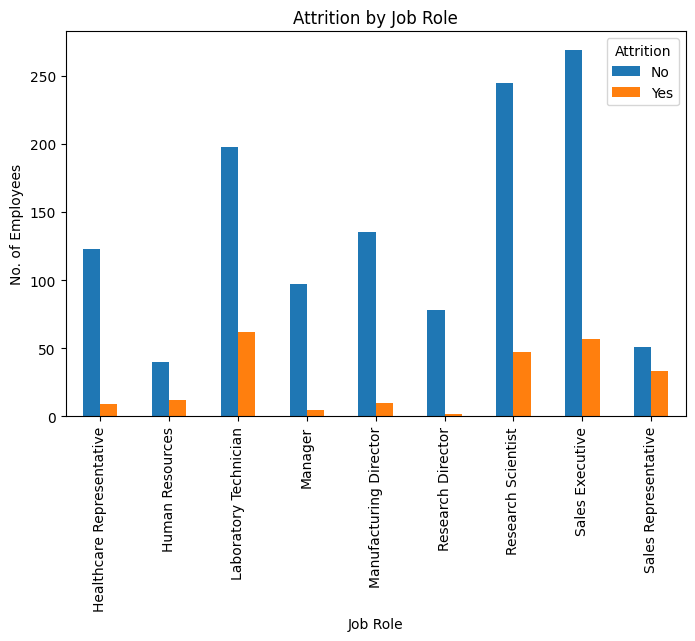

In [10]:
pd.crosstab(df['JobRole'], df['Attrition']).plot(kind='bar', figsize=(8,5))
plt.title('Attrition by Job Role')
plt.xlabel('Job Role')
plt.ylabel('No. of Employees')
plt.savefig('Attrition_by_Job_Role', dpi=300, bbox_inches='tight')
plt.show()

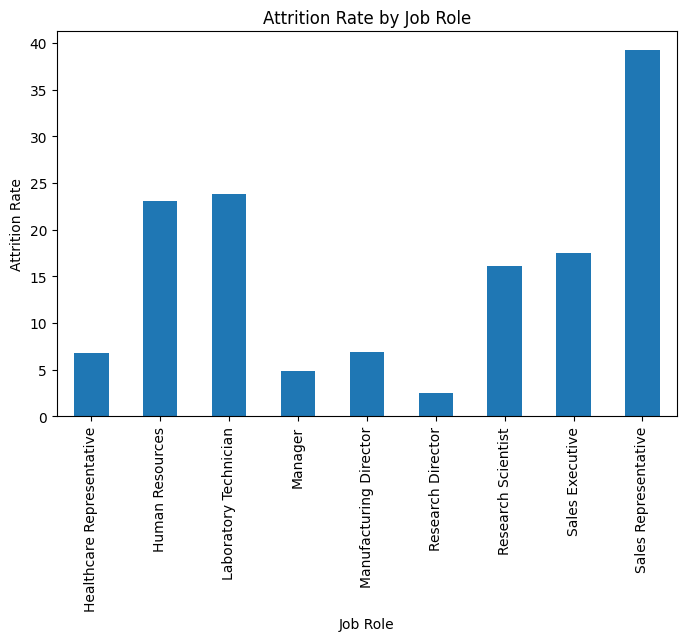

In [11]:
jobrole_arrtition_rate = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index')*100

jobrole_arrtition_rate['Yes'].plot(kind='bar', figsize=(8,5))
plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate')
plt.savefig('Attrition_Rate_by_Job_Role.png', dpi=300, bbox_inches='tight')
plt.show()

#### Attrition Rate by Age Group

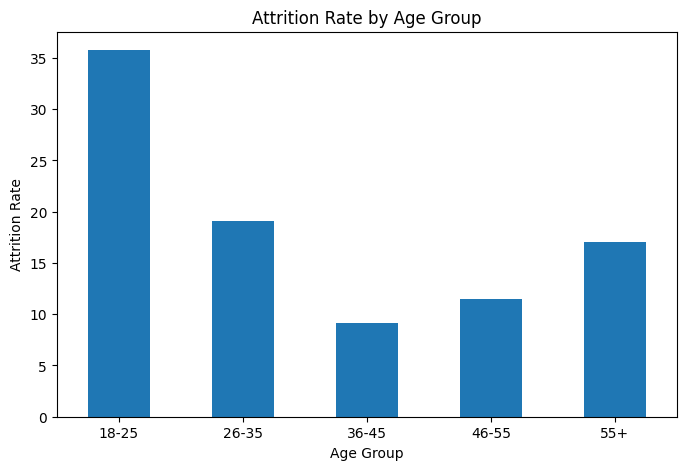

In [12]:
age_attrition_rate = pd.crosstab(df['AgeGroup'], df['Attrition'], normalize='index')*100

age_attrition_rate['Yes'].plot(kind='bar', figsize=(8,5))
plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=0)
plt.savefig('Attrition_Rate_by_Age_Group.png', dpi=300, bbox_inches='tight')
plt.show()

#### Attrition Rate by Gender


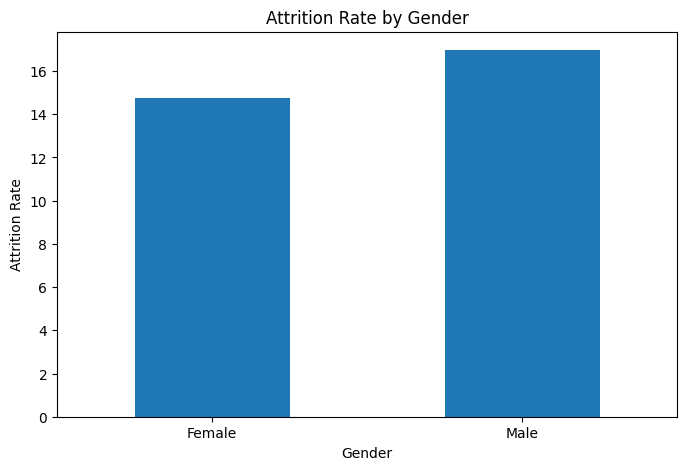

In [13]:
gender_attrition_rate = pd.crosstab(df['Gender'], df['Attrition'], normalize='index')*100

gender_attrition_rate['Yes'].plot(kind='bar', figsize=(8,5))
plt.title('Attrition Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=0)
plt.savefig('Attrition_Rate_by_Gender.png', dpi=300, bbox_inches='tight')
plt.show()

#### Attrition by Overtime

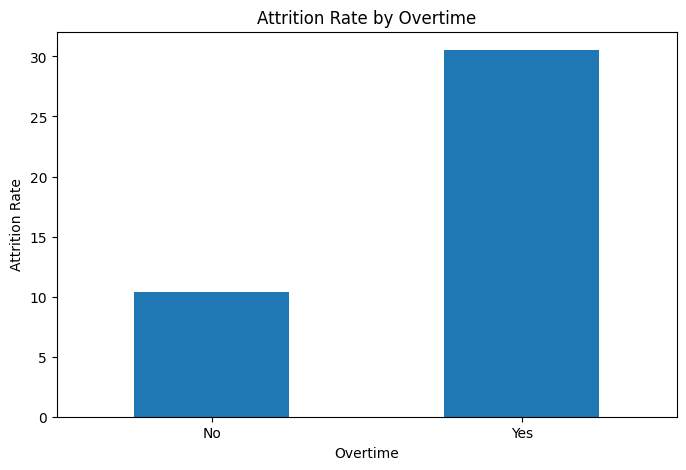

In [14]:
overtime_attrition_rate = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')*100

overtime_attrition_rate['Yes'].plot(kind='bar', figsize=(8,5))
plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=0)
plt.savefig('Attrition_Rate_by_Overtime.png', dpi=300, bbox_inches='tight')
plt.show()

#### Attrition Rate by Job Satisfaction

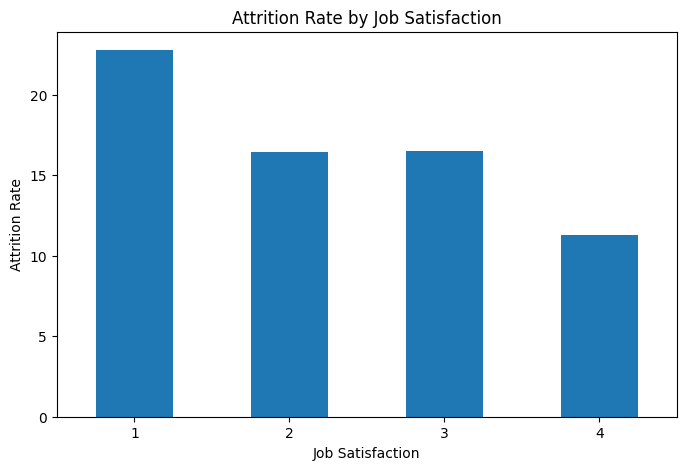

In [15]:
jobsatf_attrition_rate = pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='index')*100

jobsatf_attrition_rate['Yes'].plot(kind='bar', figsize=(8,5))
plt.title('Attrition Rate by Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=0)
plt.savefig('Attrition_Rate_by_Job Satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()

#### Attrition rate by Worklife Balance

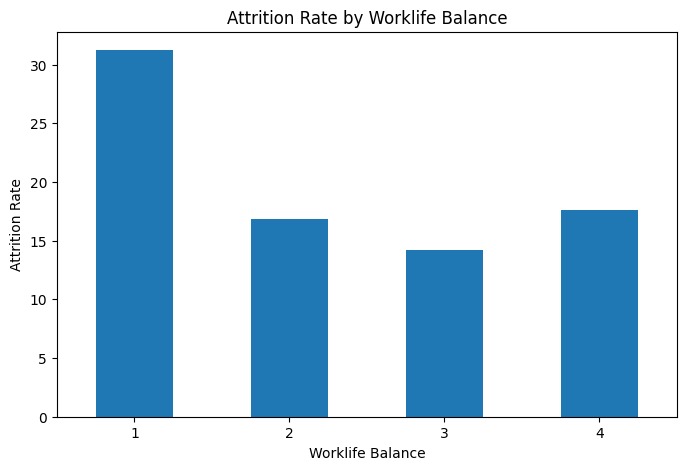

In [16]:
worklife_attrition_rate = pd.crosstab(df['WorkLifeBalance'], df['Attrition'], normalize='index')*100

worklife_attrition_rate['Yes'].plot(kind='bar', figsize=(8,5))
plt.title('Attrition Rate by Worklife Balance')
plt.xlabel('Worklife Balance')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=0)
plt.savefig('Attrition_Rate_by_Worklife_Balance.png', dpi=300, bbox_inches='tight')
plt.show()

#### Attrition by Years at Company

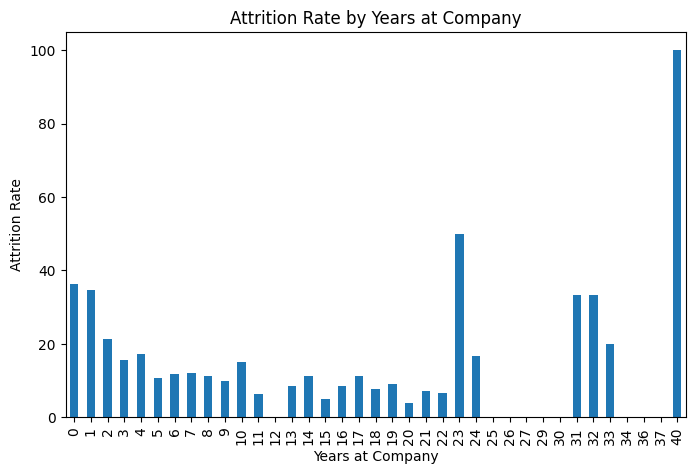

In [17]:
yearsatcompany_attrition_rate = pd.crosstab(df['YearsAtCompany'], df['Attrition'], normalize='index')*100

yearsatcompany_attrition_rate['Yes'].plot(kind='bar', figsize=(8,5))
plt.title('Attrition Rate by Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate')
plt.savefig('Attrition_Rate_by_Years_at_Company.png', dpi=300, bbox_inches='tight')
plt.show()

#### Monthly Income by Department


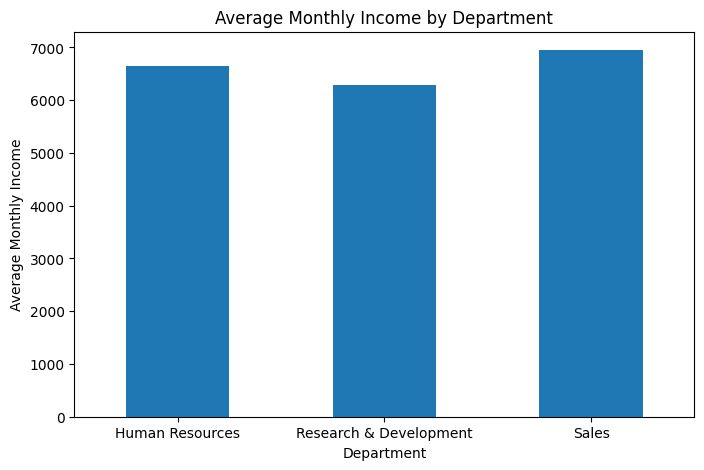

In [18]:
df.groupby('Department')['MonthlyIncome'].mean().plot(kind='bar', figsize=(8,5))
plt.title('Average Monthly Income by Department')
plt.xlabel('Department')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=0)
plt.savefig('Average_Monthly_Income_by_Department.png', dpi=300, bbox_inches='tight')
plt.show()

#### Correlation Heatmap

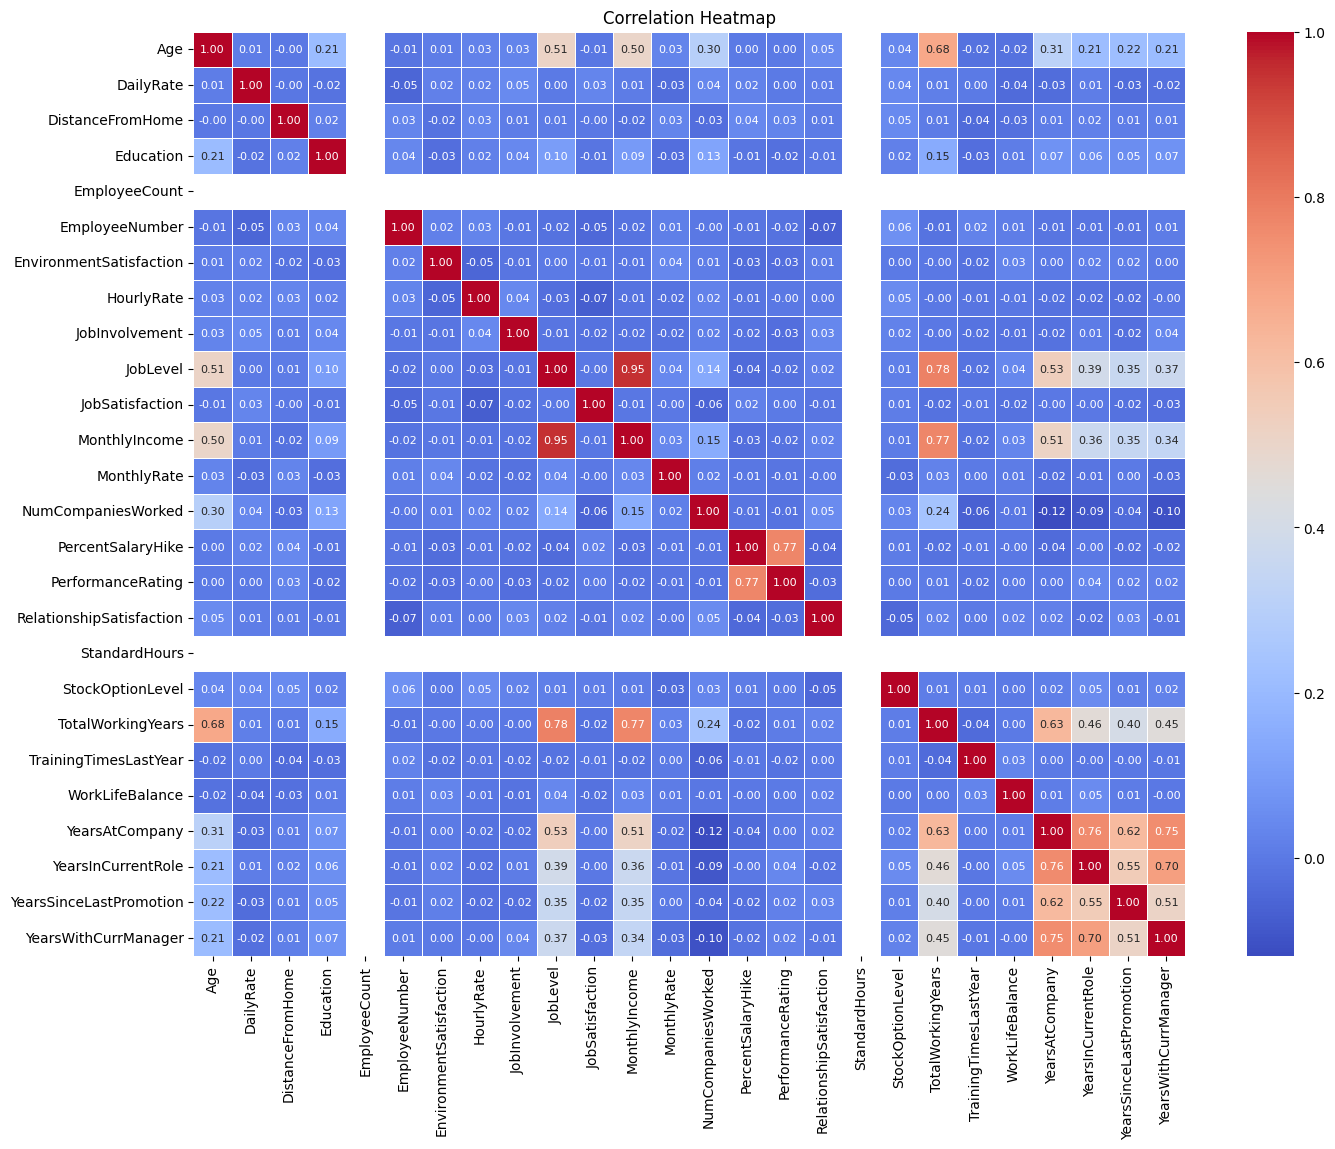

In [23]:
numeric_df = df.select_dtypes(include=('int64', 'float64'))

plt.figure(figsize=(16,12))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            annot_kws= {'size':8},
            linewidths=0.5
            )

plt.title('Correlation Heatmap')
plt.savefig('Correlation_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Saving Dataset

In [25]:
df.to_csv('HR_dataset_processed.csv',
          index=False)

## 📌 Key Insights

- The overall employee attrition rate is approximately **16%**, indicating that around one out of every six employees leaves the organization.

- The **Sales** department has the highest attrition rate, suggesting that employees in this department are more likely to leave than those in other departments.

- **Sales Representatives** and **Laboratory Technicians** experience the highest attrition among all job roles, making them priority roles for employee retention initiatives.

- Employees aged **26–35 years** show the highest attrition rate, indicating that early-career professionals are more likely to switch jobs.

- Employees who work **overtime** have a significantly higher attrition rate compared to employees who do not work overtime, highlighting workload as an important factor.

- Lower salary levels are associated with higher employee attrition, suggesting that competitive compensation may improve employee retention.

- Employees with **low job satisfaction** are more likely to leave the organization, emphasizing the importance of improving workplace satisfaction and engagement.

- Poor **work-life balance** is linked to increased attrition, indicating that flexible work policies and better workload management may help reduce employee turnover.

- Employees with fewer **years at the company** are more likely to leave, suggesting that stronger onboarding and career development programs could improve retention during the early stages of employment.

- Average monthly income varies across departments, reflecting differences in job roles, responsibilities, and experience levels.

- The correlation analysis shows a strong positive relationship between **Monthly Income**, **Job Level**, and **Total Working Years**, indicating that employee income generally increases with experience and seniority.

- Overall, overtime, job satisfaction, salary, and work-life balance are the most influential factors associated with employee attrition in this dataset.